数据集概览：
<xarray.Dataset> Size: 77kB
Dimensions:          (ISO_Time: 385)
Coordinates:
  * ISO_Time         (ISO_Time) datetime64[ns] 3kB 2024-10-24T18:00:00 ... 20...
Data variables: (12/26)
    JTWC_Vmax        (ISO_Time) float64 3kB ...
    JTWC_Lat         (ISO_Time) float64 3kB ...
    JTWC_Lon         (ISO_Time) float64 3kB ...
    RSMC_Vmax        (ISO_Time) float64 3kB ...
    RSMC_Lat         (ISO_Time) float64 3kB ...
    RSMC_Lon         (ISO_Time) float64 3kB ...
    ...               ...
    Obs_Quality      (ISO_Time) int64 3kB ...
    RMW_Uncertainty  (ISO_Time) int64 3kB ...
    ET               (ISO_Time) int64 3kB ...
    Landfall         (ISO_Time) int64 3kB ...
    Name             <U8 32B ...
    Int_ID           int64 8B ...
Attributes:
    Title:                Tropical Cyclone RMW Retrieval Products
    Name:                 KONG-REY
    Int_ID:               2421
    Start_Time:           2024-10-24 18:00
    End_Time:             2024-11-01 18:00
    Temporal_Re

C:\Users\莫兰蒂\AppData\Local\Temp\ipykernel_280948\599704781.py:109: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\莫兰蒂\AppData\Local\Temp\ipykernel_280948\599704781.py:109: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\莫兰蒂\AppData\Local\Temp\ipykernel_280948\599704781.py:109: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\莫兰蒂\AppData\Local\Temp\ipykernel_280948\599704781.py:109: UserWarning: Glyph 39118 (\N{CJK UNIFIED IDEOGRAPH-98CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\莫兰蒂\AppData\Local\Temp\ipykernel_280948\599704781.py:109: UserWarning: Glyph 24207 (\N{CJK UNIFIED IDEOGRAPH-5E8F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\莫兰蒂\AppData\Local\Temp\ipykernel_280948\599704781.py:109: UserWarning: Glyph 21015 (\N{CJK 

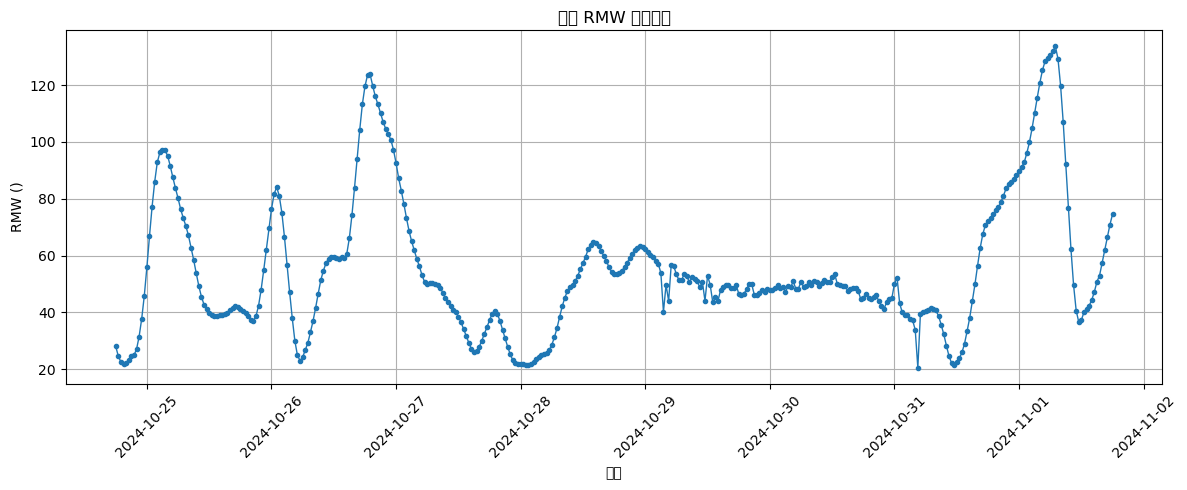


数据已保存至 rmw_data.csv


In [5]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

file_path = "2421.nc"

# 打开 NetCDF 文件
ds = xr.open_dataset(file_path)

# 查看数据集中的所有变量和维度
print("数据集概览：")
print(ds)
print("\n所有变量列表：")
for var in ds.data_vars:
    print(f"  - {var}")

# ================= 提取 RMW 相关数据 =================
# 常用 RMW 变量名（根据文件内容推测）
# 注意：实际变量名可能为 'RMW' 或 'RMW_Raw'，请根据上面打印的列表选择
rmw_var = "RMW"          # 若不存在可尝试 "RMW_Raw", "Reye", "R0" 等
if rmw_var in ds.data_vars:
    rmw = ds[rmw_var]
else:
    # 备选变量
    for candidate in ["RMW_Raw", "Reye", "R0"]:
        if candidate in ds.data_vars:
            rmw = ds[candidate]
            rmw_var = candidate
            break
    else:
        raise KeyError("未找到 RMW 相关变量，请检查上方打印的变量列表。")

print(f"\n正在读取变量: {rmw_var}")
print(f"形状: {rmw.shape}")
print(f"单位: {rmw.attrs.get('units', '无')}")
print(f"长名称: {rmw.attrs.get('long_name', '无')}")

# 查看填充值并替换为 NaN
if "_FillValue" in rmw.attrs:
    fill_value = rmw.attrs["_FillValue"]
    rmw_data = rmw.where(rmw != fill_value)
else:
    rmw_data = rmw

# 转换为 numpy 数组（保留 NaN）
rmw_values = rmw_data.values

# ================= 提取时间和位置信息 =================
# 时间变量名通常为 "ISO_Time" 或 "time"
time_var = None
for tv in ["ISO_Time", "time", "Time"]:
    if tv in ds.coords or tv in ds.data_vars:
        time_var = tv
        break
if time_var is None:
    print("\n警告：未找到标准时间变量，将使用索引作为时间轴。")
    times = pd.Index(range(len(rmw_values)), name="index")
else:
    time_data = ds[time_var]
    # 如果时间是数值（如 hours since 1970-01-01），转换为 datetime
    if "units" in time_data.attrs:
        times = pd.to_datetime(time_data.values, unit='h', origin=pd.Timestamp('1970-01-01'))
    else:
        times = time_data.values

# 获取对应的经纬度（不同机构可能不同，此处以 JTWC 为例）
lat_var = None
lon_var = None
for name in ["JTWC_Lat", "RSMC_Lat", "CMA_Lat", "lat", "latitude"]:
    if name in ds.data_vars:
        lat_var = name
        break
for name in ["JTWC_Lon", "RSMC_Lon", "CMA_Lon", "lon", "longitude"]:
    if name in ds.data_vars:
        lon_var = name
        break

if lat_var and lon_var:
    lat = ds[lat_var].values
    lon = ds[lon_var].values
    print(f"\n使用经纬度: lat={lat_var}, lon={lon_var}")
else:
    lat = lon = None
    print("\n未找到标准经纬度变量，将不显示位置信息。")

# ================= 输出数据概览 =================
print("\n===== RMW 数据前10个有效值 =====")
valid_mask = ~np.isnan(rmw_values)
valid_rmw = rmw_values[valid_mask]
valid_times = times[valid_mask] if hasattr(times, '__getitem__') else None
print(f"有效数据点数: {len(valid_rmw)}")
print(f"RMW 范围: {np.nanmin(rmw_values):.2f} ~ {np.nanmax(rmw_values):.2f} {rmw.attrs.get('units', '')}")
if valid_times is not None:
    print("时间与 RMW 对应样例（前5个）：")
    for i in range(min(5, len(valid_rmw))):
        print(f"  {valid_times[i]}  ->  {valid_rmw[i]:.2f} {rmw.attrs.get('units', '')}")

# ================= 可选：绘制时间序列 =================
if len(valid_rmw) > 0:
    plt.figure(figsize=(12, 5))
    plt.plot(times, rmw_values, 'o-', markersize=3, linewidth=1)
    plt.xlabel("时间")
    plt.ylabel(f"{rmw.attrs.get('long_name', rmw_var)} ({rmw.attrs.get('units', '')})")
    plt.title("台风 RMW 时间序列")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ================= 如果需要将数据保存为 CSV =================
# 构建 DataFrame 并保存
df = pd.DataFrame({
    'time': times,
    rmw_var: rmw_values,
    'lat': lat if lat is not None else np.nan,
    'lon': lon if lon is not None else np.nan
})
# 删除全为 NaN 的行
df = df.dropna(subset=[rmw_var], how='all')
df.to_csv("rmw_data.csv", index=False, encoding='utf-8')
print("\n数据已保存至 rmw_data.csv")

# 关闭数据集
ds.close()

In [9]:
import pandas as pd
import numpy as np

def smooth_rmw_to_6hourly(times, rmw_values, window_hours=3):
    """
    将非均匀采样的 RMW 时间序列平滑为 6 小时间隔（00,06,12,18 UTC）。
    对每个目标时刻，取前后 window_hours 小时内的所有有效点，去除最高最低后平均。

    参数
    ----------
    times : array-like of datetime-like
        原始观测时间（支持 pandas.Timestamp 或 datetime）
    rmw_values : array-like
        原始 RMW 值（已替换填充值为 NaN）
    window_hours : float, default=3
        单侧窗口宽度（小时），总窗口宽度 = 2 * window_hours

    返回
    -------
    target_times : pandas.DatetimeIndex
        6 小时间隔的目标时刻
    smoothed_rmw : numpy.ndarray
        对应目标时刻的平滑 RMW 值（NaN 表示该窗口无足够有效点）
    """
    # 确保 times 为 pandas.DatetimeIndex
    times = pd.DatetimeIndex(times)
    # 将 RMW 转为 pandas Series 便于索引
    series = pd.Series(rmw_values, index=times)

    # 生成 6 小时间隔的目标时刻
    t_min = times.min().ceil('24h')          # 向上取整到最近的 6h 整点
    t_max = times.max().floor('24h')         # 向下取整
    target_times = pd.date_range(t_min, t_max, freq='24h')

    smoothed = []
    for tt in target_times:
        # 窗口起始和结束
        start = tt - pd.Timedelta(hours=window_hours)
        end   = tt + pd.Timedelta(hours=window_hours)
        # 窗口内的有效值（剔除 NaN）
        window_vals = series.loc[start:end].dropna().values
        n = len(window_vals)
        if n >= 3:
            # 排序，去掉一个最小和一个最大，取平均
            window_vals.sort()
            trimmed = window_vals[1:-1]   # 去除最小和最大（各一个）
            avg = np.mean(trimmed)
        else:
            avg = np.nan   # 点数不足，无法去高低平均
        smoothed.append(avg)

    return target_times, np.array(smoothed)


# ========== 在您原有代码读取数据后调用 ==========
# 假设您已有：
#   times : 时间序列（如 ds[time_var] 转换后的 pandas.DatetimeIndex）
#   rmw_values : RMW 一维数组（已替换 _FillValue 为 NaN）
# 例如：
# times = pd.to_datetime(ds["ISO_Time"].values, unit='h', origin=pd.Timestamp('1970-01-01'))
# rmw_values = ds["RMW"].where(ds["RMW"] != ds["RMW"]._FillValue).values

target_times, smoothed_rmw = smooth_rmw_to_6hourly(times, rmw_values, window_hours=3)

# 打印结果
print(f"\n平滑后共 {len(target_times)} 个时刻")
print("前5个结果（时刻 | 平滑RMW）：")
for i in range(min(5, len(target_times))):
    if not np.isnan(smoothed_rmw[i]):
        print(f"  {target_times[i]}  ->  {smoothed_rmw[i]:.2f}")
    else:
        print(f"  {target_times[i]}  ->  NaN")

# 可选：保存为 CSV
df_smooth = pd.DataFrame({
    'time': target_times,
    f'{rmw_var}_smoothed_24h': smoothed_rmw
})
df_smooth.to_csv("rmw_smoothed_24hourly.csv", index=False)


平滑后共 8 个时刻
前5个结果（时刻 | 平滑RMW）：
  2024-10-25 00:00:00  ->  58.35
  2024-10-26 00:00:00  ->  64.92
  2024-10-27 00:00:00  ->  90.44
  2024-10-28 00:00:00  ->  23.10
  2024-10-29 00:00:00  ->  60.59
